## Step 1: Data Preparation & Inspection

In this step, we will:

- Load both datasets
- Inspect dataset dimensions
- Check data types
- Check missing values
- Check duplicate records
- Handle missing values
- Convert date columns into datetime format
- Create daily date columns for merging
- Before feature engineering, we inspect numerical variables for potential outliers using boxplots. Outlier detection helps identify unusually large or small values that may influence statistical summaries and model performance. In financial trading data, extreme values may represent genuine market events, so they are inspected rather than automatically removed.

In [75]:
#1. Import Required Libraries
import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

In [76]:
# Load datasets
historical_data = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index.csv")

In [4]:
#3. View First Few Records
print("Historical Data")
display(historical_data.head())

print("\nFear & Greed Index")
display(fear_greed.head())

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Index


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
#4. Dataset Dimensions
print("Historical Data Shape :", historical_data.shape)
print("Fear & Greed Shape :", fear_greed.shape)

Historical Data Shape : (211224, 16)
Fear & Greed Shape : (2644, 4)


In [6]:
#5. Column Information
print("Historical Data Info")
historical_data.info()

print("\nFear & Greed Info")
fear_greed.info()

Historical Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtyp

In [7]:
#6. Missing Values
print("Missing Values in Historical Data")
print(historical_data.isnull().sum())

print("\nMissing Values in Fear & Greed")
print(fear_greed.isnull().sum())

Missing Values in Historical Data
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Fear & Greed
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
#7. Duplicate Records
print("Historical Data Duplicates :", historical_data.duplicated().sum())

print("Fear & Greed Duplicates :", fear_greed.duplicated().sum())

Historical Data Duplicates : 0
Fear & Greed Duplicates : 0


In [77]:
# Convert Timestamp IST to datetime
historical_data["Timestamp IST"] = pd.to_datetime(
    historical_data["Timestamp IST"],
    errors="coerce"
)

# Create daily date for merging
historical_data["trade_date"] = historical_data["Timestamp IST"].dt.date

In [78]:
fear_greed["date"] = pd.to_datetime(
    fear_greed["date"],
    errors="coerce"
)

fear_greed["trade_date"] = fear_greed["date"].dt.date

In [10]:
print(historical_data.dtypes)

print()

print(fear_greed.dtypes)

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST       datetime64[ns]
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp           datetime64[ns]
trade_date                  object
dtype: object

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
trade_date                object
dtype: object


In [79]:
# Remove leading/trailing spaces
historical_data["Coin"] = historical_data["Coin"].str.strip()

# Convert to uppercase (optional)
historical_data["Coin"] = historical_data["Coin"].str.upper()

In [13]:
historical_data["Coin"].unique()

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'KPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'KSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'KBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO

In [14]:
historical_data["Coin"].value_counts()

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@48         1
@135        1
@21         1
@42         1
@32         1
Name: count, Length: 246, dtype: int64

In [80]:
# Select numerical columns
numerical_columns = historical_data.select_dtypes(include=["int64", "float64"]).columns

print(numerical_columns)

Index(['Execution Price', 'Size Tokens', 'Size USD', 'Start Position',
       'Closed PnL', 'Order ID', 'Fee', 'Trade ID', 'Timestamp'],
      dtype='object')


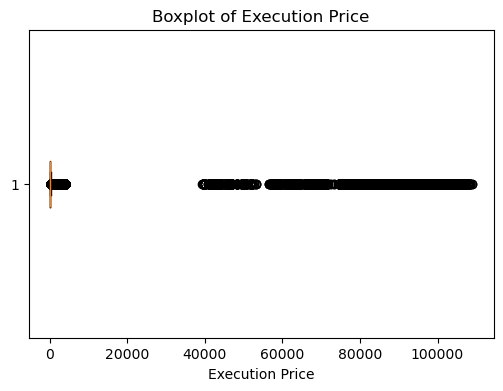

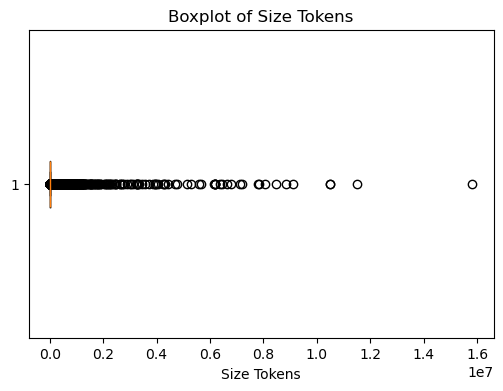

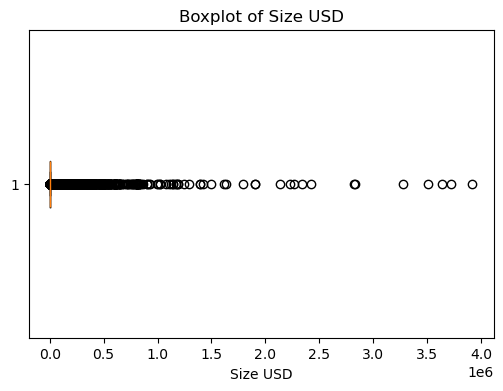

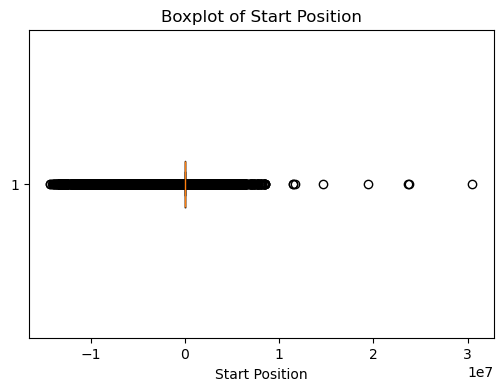

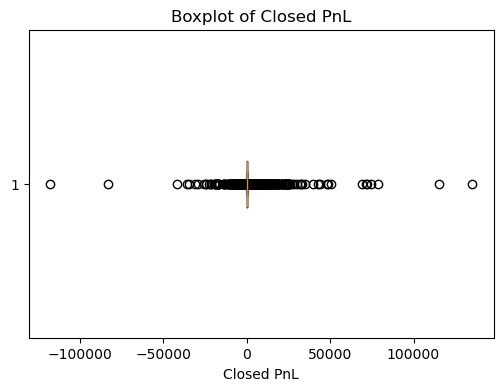

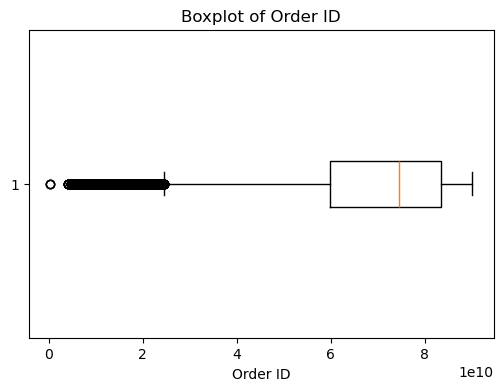

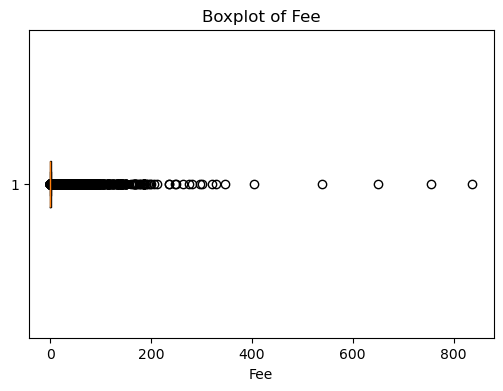

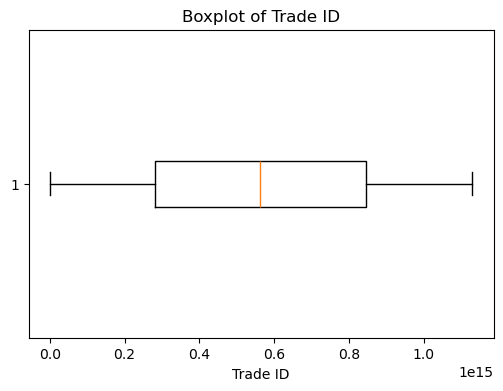

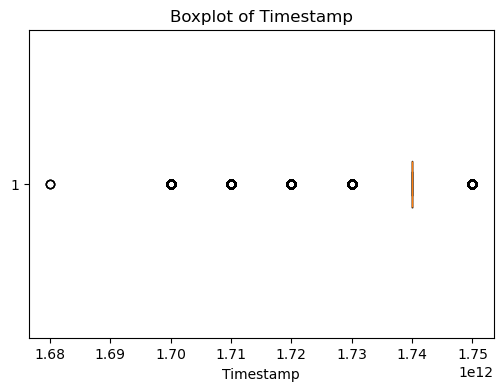

In [81]:
#Boxplots for Outlier Detection
import matplotlib.pyplot as plt

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(historical_data[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [83]:
#Count Outliers Using IQR
for col in numerical_columns:
    Q1 = historical_data[col].quantile(0.25)
    Q3 = historical_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = historical_data[
        (historical_data[col] < lower) |
        (historical_data[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Execution Price: 42187 outliers
Size Tokens: 34744 outliers
Size USD: 32661 outliers
Start Position: 58346 outliers
Closed PnL: 48941 outliers
Order ID: 9213 outliers
Fee: 30278 outliers
Trade ID: 0 outliers
Timestamp: 77353 outliers


In [19]:
#Statistical Summary
historical_data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.0,1.141472e+04,2.944765e+04,4.530000e-06,4.854700e+00,1.828000e+01,1.015800e+02,1.090040e+05
Size Tokens,211224.0,4.623365e+03,1.042729e+05,8.740000e-07,2.940000e+00,3.200000e+01,1.879025e+02,1.582244e+07
Size USD,211224.0,5.639451e+03,3.657514e+04,0.000000e+00,1.937900e+02,5.970450e+02,2.058960e+03,3.921431e+06
Start Position,211224.0,-2.994625e+04,6.738074e+05,-1.433463e+07,-3.762311e+02,8.472793e+01,9.337278e+03,3.050948e+07
Closed PnL,211224.0,4.874900e+01,9.191648e+02,-1.179901e+05,0.000000e+00,0.000000e+00,5.792797e+00,1.353291e+05
Order ID,211224.0,6.965388e+10,1.835753e+10,1.732711e+08,5.983853e+10,7.442939e+10,8.335543e+10,9.014923e+10
Fee,211224.0,1.163967e+00,6.758854e+00,-1.175712e+00,1.612094e-02,8.957750e-02,3.938110e-01,8.374716e+02
Trade ID,211224.0,5.628549e+14,3.257565e+14,0.000000e+00,2.810000e+14,5.620000e+14,8.460000e+14,1.130000e+15


## Data Preparation Summary

- Loaded both datasets successfully.
- Inspected dataset dimensions and column types.
- Checked missing values and duplicates.
- Converted timestamp columns into datetime format.
- The `Coin` column contains cryptocurrency trading symbols (e.g., BTC, ETH, SOL, 1000PEPE). No cleaning was required because these values represent valid trading instruments. Only whitespace (if any) was removed to ensure consistency.
- Outliers were detected in several numerical variables such as **Closed PnL**, **Execution Price**, **Size USD**, and **Fee** using boxplots and the IQR method.

Since this dataset contains real cryptocurrency trading records, these extreme values likely represent genuine high-profit, high-loss, or high-volume trades rather than data errors. Removing them could distort the analysis of trader behavior and performance.

Therefore, no outliers were removed, and all observations were retained for further analysis.

# Step 2: Feature Engineering & Data Merging

In this step, we will:

- Create new features to measure daily trader performance and trading behavior.
- Since the dataset does not contain a **Leverage** column, a **Position Exposure Proxy** is created using the available trade information (`Size USD`). This proxy represents the relative trade exposure and is used instead of leverage for subsequent analysis.
- Calculate daily aggregated metrics for each trader, including:
  - Daily Profit & Loss (PnL)
  - Total Number of Trades
  - Win Rate
  - Average Trade Size
  - Average Position Exposure (Proxy)
  - Long and Short Trade Counts
  - Long/Short Ratio
  - Drawdown Proxy (Largest Daily Loss)
- Merge the daily trader metrics with the Bitcoin Fear & Greed Index using the common `trade_date`.
- Categorize market sentiment into two macro states:
  - **Fear** (Fear + Extreme Fear)
  - **Greed** (Greed + Extreme Greed)
- Prepare the final merged dataset for behavioral analysis and visualization.

In [84]:
#2.1 Create a Win/Loss Column
# Win = 1, Loss = 0
historical_data["Win"] = (historical_data["Closed PnL"] > 0).astype(int)

In [85]:
#2.2 Create Trade Direction Columns
historical_data["Long"] = (historical_data["Side"] == "BUY").astype(int)

historical_data["Short"] = (historical_data["Side"] == "SELL").astype(int)

In [86]:
# Position Exposure Proxy
historical_data["Position_Exposure"] = historical_data["Size USD"]

In [87]:
#2.3 Create Daily Trader Metrics
daily_metrics = (
    historical_data
    .groupby(["Account", "trade_date"])
    .agg(
        Daily_PnL=("Closed PnL", "sum"),
        Total_Trades=("Closed PnL", "count"),
        Win_Rate=("Win", "mean"),
        Avg_Trade_Size=("Size USD", "mean"),
        Avg_Position_Exposure=("Position_Exposure", "mean"),
        Long_Trades=("Long", "sum"),
        Short_Trades=("Short", "sum"),
        Largest_Loss=("Closed PnL", "min")
    )
    .reset_index()
)

In [88]:
daily_metrics.head()

,Account,trade_date,Daily_PnL,Total_Trades,Win_Rate,Avg_Trade_Size,Avg_Position_Exposure,Long_Trades,Short_Trades,Largest_Loss
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,33,0.000000,36736.362424,36736.362424,33,0,-117990.10410
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,5089.718249,0,177,0.00000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,45,0.800000,2985.797556,2985.797556,36,9,0.00000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,10,0.900000,185847.000000,185847.000000,9,1,0.00000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,839,0.305125,23593.019857,23593.019857,350,489,-19841.24014


In [89]:
#2.4 Convert Win Rate to Percentage
daily_metrics["Win_Rate"] = daily_metrics["Win_Rate"] * 100

In [90]:
#2.5 Calculate Long/Short Ratio
daily_metrics["Long_Short_Ratio"] = (
    daily_metrics["Long_Trades"] /
    daily_metrics["Short_Trades"].replace(0, np.nan)
)

In [91]:
#2.6 Rename Drawdown Proxy
daily_metrics.rename(
    columns={"Largest_Loss": "Drawdown_Proxy"},
    inplace=True
)

In [92]:
#2.7 Merge with Fear & Greed Dataset
merged_data = pd.merge(
    daily_metrics,
    fear_greed[["trade_date", "classification"]],
    on="trade_date",
    how="inner"
)

In [93]:
#2.8 Create Macro Sentiment
merged_data["Market_Sentiment"] = merged_data["classification"].replace({
    "Fear": "Fear",
    "Extreme Fear": "Fear",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})

In [94]:
#2.9 Check the Final Dataset
merged_data.head()

,Account,trade_date,Daily_PnL,Total_Trades,Win_Rate,Avg_Trade_Size,Avg_Position_Exposure,Long_Trades,Short_Trades,Drawdown_Proxy,Long_Short_Ratio,classification,Market_Sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,33,0.000000,36736.362424,36736.362424,33,0,-117990.10410,NaN,Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,5089.718249,0,177,0.00000,0.000000,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,45,80.000000,2985.797556,2985.797556,36,9,0.00000,4.000000,Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,10,90.000000,185847.000000,185847.000000,9,1,0.00000,9.000000,Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,839,30.512515,23593.019857,23593.019857,350,489,-19841.24014,0.715746,Fear,Fear


In [95]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Account                530 non-null    object 
 1   trade_date             530 non-null    object 
 2   Daily_PnL              530 non-null    float64
 3   Total_Trades           530 non-null    int64  
 4   Win_Rate               530 non-null    float64
 5   Avg_Trade_Size         530 non-null    float64
 6   Avg_Position_Exposure  530 non-null    float64
 7   Long_Trades            530 non-null    int64  
 8   Short_Trades           530 non-null    int64  
 9   Drawdown_Proxy         530 non-null    float64
 10  Long_Short_Ratio       403 non-null    float64
 11  classification         530 non-null    object 
 12  Market_Sentiment       530 non-null    object 
dtypes: float64(6), int64(3), object(4)
memory usage: 54.0+ KB


In [96]:
merged_data.shape

(530, 13)

## Step 2 Summary

In this step:

- Created new performance and behavioral features for each trader on a daily basis.
- Generated a **Position Exposure Proxy** using the `Size USD` column because the dataset did not include a leverage field. This proxy was used to represent trade exposure in subsequent analyses.
- Calculated daily metrics such as:
  - Daily PnL
  - Total Trades
  - Win Rate
  - Average Trade Size
  - Average Position Exposure
  - Long/Short Ratio
  - Drawdown Proxy
- Merged the aggregated trader metrics with the Bitcoin Fear & Greed Index using the `trade_date` column.
- Grouped market sentiment into two macro categories (**Fear** and **Greed**) to facilitate comparative analysis.
- Prepared the final merged dataset for behavioral analysis, trader segmentation, and visualization.

## Step 3: Behavioral & Performance Analysis

In this step, we will:

- Analyze how trader performance differs between **Fear** and **Greed** market conditions.
- Compare key performance metrics such as:
  - Daily Profit & Loss (PnL)
  - Win Rate
  - Drawdown Proxy
- Examine changes in trader behavior across different market sentiments, including:
  - Total Number of Trades
  - Average Trade Size
  - Average Position Exposure (Proxy)
  - Long/Short Ratio
- Compute descriptive statistics (Mean, Median, and Standard Deviation) to summarize trader performance and behavior.
- Generate statistical summaries that will be used to derive actionable insights in the next steps.

In [97]:
#3.1 Performance Comparison
#Daily PnL
pnl_summary = merged_data.groupby("Market_Sentiment")["Daily_PnL"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Daily PnL Summary")
display(pnl_summary)


Daily PnL Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,9387.502733,229.993075,50956.992391
Greed,5830.119499,130.487079,40369.770282
Neutral,2017.749783,87.752181,5609.700498


In [98]:
#Win Rate
winrate_summary = merged_data.groupby("Market_Sentiment")["Win_Rate"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Win Rate Summary")
display(winrate_summary)

Win Rate Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,31.926902,26.877407,32.451984
Greed,34.677073,29.629630,34.385543
Neutral,31.252370,21.052632,33.982129


In [99]:
#Drawdown Proxy
drawdown_summary = merged_data.groupby("Market_Sentiment")["Drawdown_Proxy"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Drawdown Proxy Summary")
display(drawdown_summary)

Drawdown Proxy Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,-296.921533,0.0,1957.257496
Greed,-648.086249,0.0,6952.457644
Neutral,-80.769083,0.0,227.296130


In [100]:
#3.2 Behavioral Analysis
#Trade Frequency
trade_summary = merged_data.groupby("Market_Sentiment")["Total_Trades"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Trade Frequency Summary")
display(trade_summary)

Trade Frequency Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,85.236842,31.5,157.178535
Greed,55.818482,19.0,118.406095
Neutral,74.486486,33.0,155.494484


In [101]:
#Average Trade Size
trade_size_summary = merged_data.groupby("Market_Sentiment")["Avg_Trade_Size"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Average Trade Size Summary")
display(trade_size_summary)

Average Trade Size Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,7539.752824,1973.166942,13805.033520
Greed,7029.004130,2585.338000,13680.850886
Neutral,5763.624619,1585.403333,7601.604166


In [102]:
#Position Exposure (Proxy)
exposure_summary = merged_data.groupby("Market_Sentiment")["Avg_Position_Exposure"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Position Exposure Summary")
display(exposure_summary)

Position Exposure Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,7539.752824,1973.166942,13805.033520
Greed,7029.004130,2585.338000,13680.850886
Neutral,5763.624619,1585.403333,7601.604166


In [103]:
#Long / Short Ratio
long_short_summary = merged_data.groupby("Market_Sentiment")["Long_Short_Ratio"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std"
)

print("Long / Short Ratio Summary")
display(long_short_summary)

Long / Short Ratio Summary


,Mean,Median,Std_Dev
Market_Sentiment,,,
Fear,2.482443,0.653061,6.534897
Greed,1.564141,0.634129,3.765261
Neutral,0.882250,0.447273,1.129593


In [104]:
#3.3 Combined Summary Table
summary_table = merged_data.groupby("Market_Sentiment").agg({

    "Daily_PnL":["mean","median","std"],
    "Win_Rate":["mean","median","std"],
    "Drawdown_Proxy":["mean","median","std"],
    "Total_Trades":["mean","median","std"],
    "Avg_Trade_Size":["mean","median","std"],
    "Avg_Position_Exposure":["mean","median","std"],
    "Long_Short_Ratio":["mean","median","std"]

})

summary_table

Daily_PnL                             Win_Rate             \
                         mean      median           std       mean     median   
Market_Sentiment                                                                
Fear              9387.502733  229.993075  50956.992391  31.926902  26.877407   
Greed             5830.119499  130.487079  40369.770282  34.677073  29.629630   
Neutral           2017.749783   87.752181   5609.700498  31.252370  21.052632   

                            Drawdown_Proxy                     Total_Trades  \
                        std           mean median          std         mean   
Market_Sentiment                                                              
Fear              32.451984    -296.921533    0.0  1957.257496    85.236842   
Greed             34.385543    -648.086249    0.0  6952.457644    55.818482   
Neutral           33.982129     -80.769083    0.0   227.296130    74.486486   

                                    Avg_Trade_Size                             \
                 median         std           mean       median           std   
Market_Sentiment                                                                
Fear               31.5  157.178535    7539.752824  1973.166942  13805.033520   
Greed              19.0  118.406095    7029.004130  2585.338000  13680.850886   
Neutral            33.0  155.494484    5763.624619  1585.403333   7601.604166   

                 Avg_Position_Exposure                             \
                                  mean       median           std   
Market_Sentiment                                                    
Fear                       7539.752824  1973.166942  13805.033520   
Greed                      7029.004130  2585.338000  13680.850886   
Neutral                    5763.624619  1585.403333   7601.604166   

                 Long_Short_Ratio                      
                             mean    median       std  
Market_Sentiment                                       
Fear                     2.482443  0.653061  6.534897  
Greed                    1.564141  0.634129  3.765261  
Neutral                  0.882250  0.447273  1.129593

In [106]:
#Statistical Significance Test
from scipy.stats import mannwhitneyu

metrics = [
    "Daily_PnL",
    "Win_Rate",
    "Total_Trades",
    "Avg_Trade_Size",
    "Avg_Position_Exposure",
    "Drawdown_Proxy"
]

for metric in metrics:
    fear = merged_data[merged_data["Market_Sentiment"] == "Fear"][metric].dropna()
    greed = merged_data[merged_data["Market_Sentiment"] == "Greed"][metric].dropna()

    stat, p = mannwhitneyu(fear, greed)

    print(f"\n{metric}")
    print(f"U Statistic : {stat:.2f}")
    print(f"P-value     : {p:.4f}")

    if p < 0.05:
        print("Result      : Significant Difference")
    else:
        print("Result      : No Significant Difference")


Daily_PnL
U Statistic : 29719.00
P-value     : 0.5379
Result      : No Significant Difference

Win_Rate
U Statistic : 27626.00
P-value     : 0.4410
Result      : No Significant Difference

Total_Trades
U Statistic : 32859.00
P-value     : 0.0081
Result      : Significant Difference

Avg_Trade_Size
U Statistic : 28247.00
P-value     : 0.7270
Result      : No Significant Difference

Avg_Position_Exposure
U Statistic : 28247.00
P-value     : 0.7270
Result      : No Significant Difference

Drawdown_Proxy
U Statistic : 28250.50
P-value     : 0.6760
Result      : No Significant Difference


## Step 3 Summary

In this step, trader performance and trading behavior were analyzed under different market sentiment conditions (Fear and Greed).

### Performance Analysis

The following performance metrics were compared between Fear and Greed market conditions:

- Daily Profit and Loss (PnL)
- Win Rate
- Drawdown Proxy (Largest Daily Loss)

Descriptive statistics, including **Mean**, **Median**, and **Standard Deviation**, were calculated to understand the distribution of trader performance under different market sentiments.

### Behavioral Analysis

The following trading behavior metrics were analyzed:

- Total Number of Trades
- Average Trade Size
- Average Position Exposure (Proxy)
- Long/Short Ratio

These metrics were used to evaluate whether traders changed their trading activity and behavior during Fear and Greed market conditions.

### Statistical Significance Test

A **Mann–Whitney U Test** was performed to compare the performance and behavioral metrics between Fear and Greed market conditions.

| Metric | Statistical Result |
|--------|--------------------|
| Daily PnL | No Significant Difference |
| Win Rate | No Significant Difference |
| Total Number of Trades | **Significant Difference** |
| Average Trade Size | No Significant Difference |
| Average Position Exposure | No Significant Difference |
| Drawdown Proxy | No Significant Difference |

### Key Findings

- Daily Profit and Loss (PnL) did not show a statistically significant difference between Fear and Greed market conditions.
- Win Rate remained statistically similar across both market sentiment states.
- **Total Number of Trades showed a statistically significant difference**, indicating that traders modify their trading frequency based on market sentiment.
- Average Trade Size and Average Position Exposure did not differ significantly between Fear and Greed market conditions.
- Drawdown Proxy also showed no statistically significant difference across the two market sentiment groups.

### Conclusion

The analysis indicates that **market sentiment primarily influences trading frequency**, while trader profitability, win rate, trade size, position exposure, and drawdown remain relatively stable across Fear and Greed market conditions. These findings provide a foundation for trader segmentation and further behavioral analysis in the next step.

# Step 4: Trader Segmentation

In this step, traders are segmented into different behavioral groups based on their trading characteristics. The objective is to understand how different types of traders perform under varying market sentiment conditions.

The following trader segments are created:

- **High Exposure vs. Low Exposure Traders** based on the median Average Position Exposure.
- **Frequent vs. Infrequent Traders** based on the median Daily Trade Count.
- **Consistent Winners vs. Inconsistent Traders** based on Overall Win Rate.

The performance of each segment is then compared across Fear and Greed market conditions to identify differences in profitability and trading behavior.

In [107]:
#4.1 High Exposure vs Low Exposure
# Median Position Exposure
median_exposure = merged_data["Avg_Position_Exposure"].median()

merged_data["Exposure_Segment"] = np.where(
    merged_data["Avg_Position_Exposure"] >= median_exposure,
    "High Exposure",
    "Low Exposure"
)

merged_data["Exposure_Segment"].value_counts()

Exposure_Segment
High Exposure    265
Low Exposure     265
Name: count, dtype: int64

In [108]:
#4.2 Frequent vs Infrequent Traders
median_trades = merged_data["Total_Trades"].median()

merged_data["Trader_Frequency"] = np.where(
    merged_data["Total_Trades"] >= median_trades,
    "Frequent Trader",
    "Infrequent Trader"
)

merged_data["Trader_Frequency"].value_counts()

Trader_Frequency
Frequent Trader      271
Infrequent Trader    259
Name: count, dtype: int64

In [109]:
#4.3 Consistent Winners vs Inconsistent Traders
overall_winrate = (
    historical_data
    .groupby("Account")["Win"]
    .mean()
    .reset_index()
)

overall_winrate["Overall_Win_Rate"] = overall_winrate["Win"] * 100

overall_winrate.head()

,Account,Win,Overall_Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


In [110]:
#Create Winner Segment
overall_winrate["Winner_Segment"] = np.where(
    overall_winrate["Overall_Win_Rate"] > 55,
    "Consistent Winner",
    "Inconsistent Trader"
)

In [112]:
#Merge back
merged_data = merged_data.merge(
    overall_winrate[["Account","Winner_Segment"]],
    on="Account",
    how="left"
)

In [115]:
#Check Segments
merged_data.head()

,Account,trade_date,Daily_PnL,Total_Trades,Win_Rate,Avg_Trade_Size,Avg_Position_Exposure,Long_Trades,Short_Trades,Drawdown_Proxy,Long_Short_Ratio,classification,Market_Sentiment,Exposure_Segment,Trader_Frequency,Winner_Segment_x,Winner_Segment_y
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,33,0.000000,36736.362424,36736.362424,33,0,-117990.10410,NaN,Greed,Greed,High Exposure,Frequent Trader,Inconsistent Trader,Inconsistent Trader
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,5089.718249,0,177,0.00000,0.000000,Extreme Greed,Greed,High Exposure,Frequent Trader,Inconsistent Trader,Inconsistent Trader
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,45,80.000000,2985.797556,2985.797556,36,9,0.00000,4.000000,Greed,Greed,High Exposure,Frequent Trader,Inconsistent Trader,Inconsistent Trader
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,10,90.000000,185847.000000,185847.000000,9,1,0.00000,9.000000,Greed,Greed,High Exposure,Infrequent Trader,Inconsistent Trader,Inconsistent Trader
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,839,30.512515,23593.019857,23593.019857,350,489,-19841.24014,0.715746,Fear,Fear,High Exposure,Frequent Trader,Inconsistent Trader,Inconsistent Trader


In [116]:
#4.4 Segment-wise Performance Analysis
exposure_analysis = merged_data.groupby(
    ["Exposure_Segment","Market_Sentiment"]
).agg(
    Average_PnL=("Daily_PnL","mean"),
    Average_WinRate=("Win_Rate","mean"),
    Average_Trades=("Total_Trades","mean"),
    Average_Exposure=("Avg_Position_Exposure","mean")
)

display(exposure_analysis)

Average_PnL  Average_WinRate  \
Exposure_Segment Market_Sentiment                                  
High Exposure    Fear              18760.734798        32.779371   
                 Greed              5577.035769        36.024751   
                 Neutral            2286.563083        23.386080   
Low Exposure     Fear               1300.792716        31.191438   
                 Greed              6117.066546        33.149071   
                 Neutral            1812.939650        37.245734   

                                   Average_Trades  Average_Exposure  
Exposure_Segment Market_Sentiment                                    
High Exposure    Fear                   93.000000      15265.623900  
                 Greed                  58.105590      12554.980981  
                 Neutral                54.875000      12439.872601  
Low Exposure     Fear                   78.539216        874.295426  
                 Greed                  53.225352        763.636009  
                 Neutral                89.428571        676.959490

In [117]:
#Trader Frequency
frequency_analysis = merged_data.groupby(
    ["Trader_Frequency","Market_Sentiment"]
).agg(
    Average_PnL=("Daily_PnL","mean"),
    Average_WinRate=("Win_Rate","mean"),
    Average_Trades=("Total_Trades","mean")
)

display(frequency_analysis)

Average_PnL  Average_WinRate  \
Trader_Frequency  Market_Sentiment                                  
Frequent Trader   Fear              14773.139706        38.320276   
                  Greed             11380.975364        40.346423   
                  Neutral            3573.018684        43.757843   
Infrequent Trader Fear               1654.280412        22.746672   
                  Greed              1125.430687        29.871953   
                  Neutral             188.021665        16.540049   

                                    Average_Trades  
Trader_Frequency  Market_Sentiment                  
Frequent Trader   Fear                  139.267857  
                  Greed                 111.417266  
                  Neutral               132.050000  
Infrequent Trader Fear                    7.653846  
                  Greed                   8.695122  
                  Neutral                 6.764706

In [124]:
merged_data.drop(columns=["Winner_Segment_y"], inplace=True)

merged_data.rename(
    columns={"Winner_Segment_x": "Winner_Segment"},
    inplace=True
)

In [125]:
#Winner Segment
winner_analysis = merged_data.groupby(
    ["Winner_Segment","Market_Sentiment"]
).agg(
    Average_PnL=("Daily_PnL","mean"),
    Average_WinRate=("Win_Rate","mean"),
    Average_Trades=("Total_Trades","mean")
)

display(winner_analysis)


Average_PnL  Average_WinRate  \
Winner_Segment      Market_Sentiment                                  
Consistent Winner   Fear               2315.811055        55.358235   
                    Greed              4143.344286        62.385176   
                    Neutral            4641.172904        37.326797   
Inconsistent Trader Fear              10082.408851        29.624401   
                    Greed              5988.444970        32.076312   
                    Neutral            1607.839921        30.303241   

                                      Average_Trades  
Winner_Segment      Market_Sentiment                  
Consistent Winner   Fear                   52.176471  
                    Greed                  51.615385  
                    Neutral                68.800000  
Inconsistent Trader Fear                   88.485549  
                    Greed                  56.212996  
                    Neutral                75.375000

## Step 4 Summary

In this step, traders were segmented into three behavioral categories based on their trading characteristics to better understand their performance under different market sentiment conditions. Since the dataset did not contain a leverage column, **Average Position Exposure** was used as a proxy to classify traders into **High Exposure** and **Low Exposure** groups. Traders were also categorized as **Frequent** or **Infrequent Traders** based on the median daily trade count and as **Consistent Winners** or **Inconsistent Traders** based on their overall win rate.

After creating these segments, the performance of each group was analyzed under both **Fear** and **Greed** market conditions by comparing metrics such as **Average Daily PnL, Win Rate, Total Trades, and Average Position Exposure**. This segmentation provides a deeper understanding of how different trader profiles respond to changing market sentiment and helps identify behavioral patterns that can be used to develop data-driven trading strategies. The segmented dataset also serves as the foundation for the visualizations and strategy recommendations presented in the following steps.

# Charts

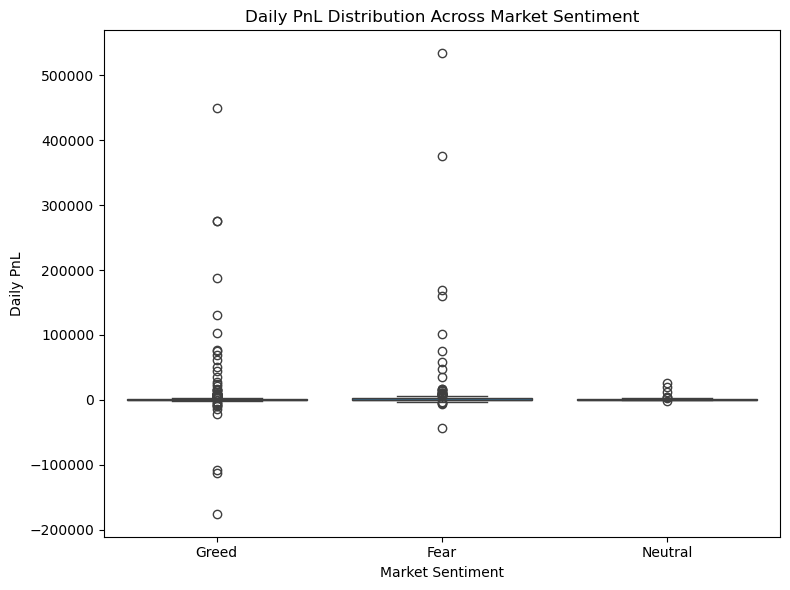

In [127]:
#Chart 1: Daily PnL Distribution by Market Sentiment (Box Plot)
#Purpose: Compare trader profitability under Fear vs. Greed.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=merged_data,
    x="Market_Sentiment",
    y="Daily_PnL"
)

plt.title("Daily PnL Distribution Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")

plt.tight_layout()
plt.savefig("images/chart1_pnl_distribution.png", dpi=300)
plt.show()

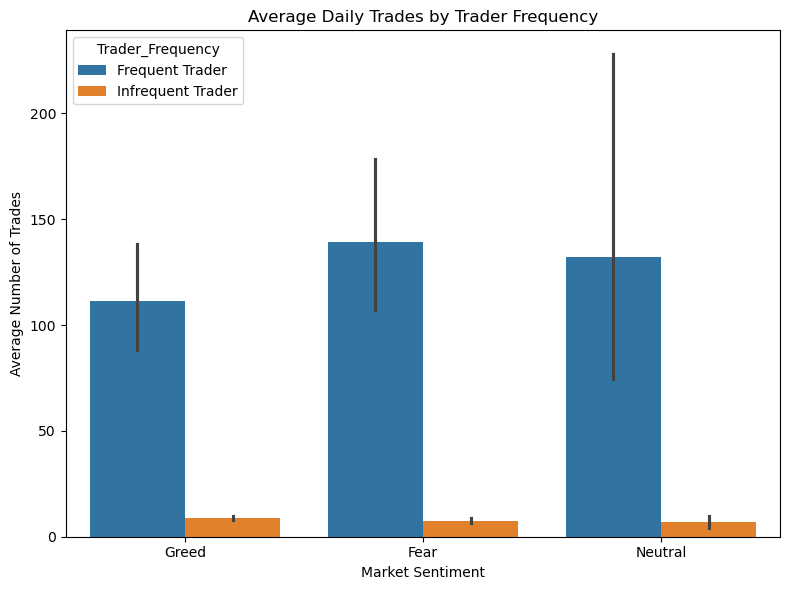

In [128]:
#Chart 2: Average Trades by Trader Frequency & Market Sentiment (Grouped Bar Chart)
#Purpose: Show behavioral changes in trading activity.
plt.figure(figsize=(8,6))

sns.barplot(
    data=merged_data,
    x="Market_Sentiment",
    y="Total_Trades",
    hue="Trader_Frequency",
    estimator="mean"
)

plt.title("Average Daily Trades by Trader Frequency")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Number of Trades")

plt.tight_layout()
plt.savefig("images/chart2_trade_frequency.png", dpi=300)
plt.show()

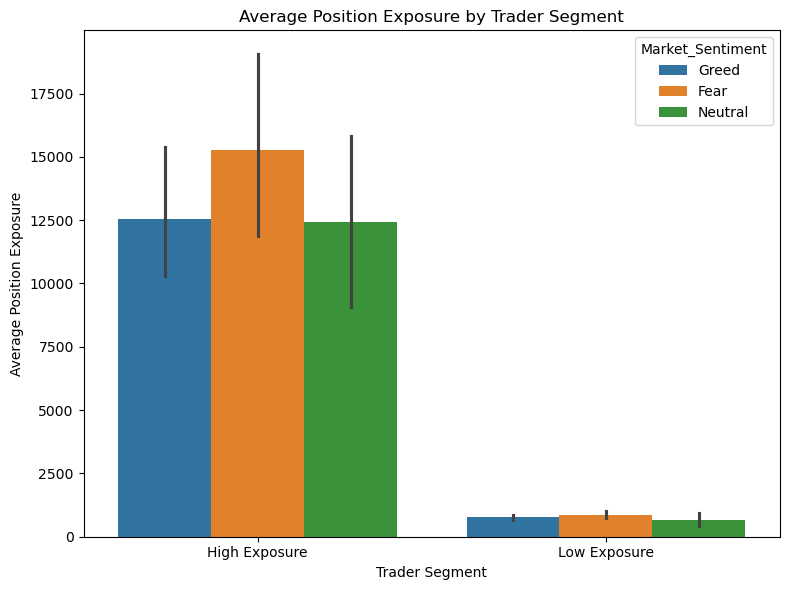

In [129]:
#Chart 3: Position Exposure by Exposure Segment
plt.figure(figsize=(8,6))

sns.barplot(
    data=merged_data,
    x="Exposure_Segment",
    y="Avg_Position_Exposure",
    hue="Market_Sentiment",
    estimator="mean"
)

plt.title("Average Position Exposure by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Position Exposure")

plt.tight_layout()
plt.savefig("images/chart3_position_exposure.png", dpi=300)
plt.show()

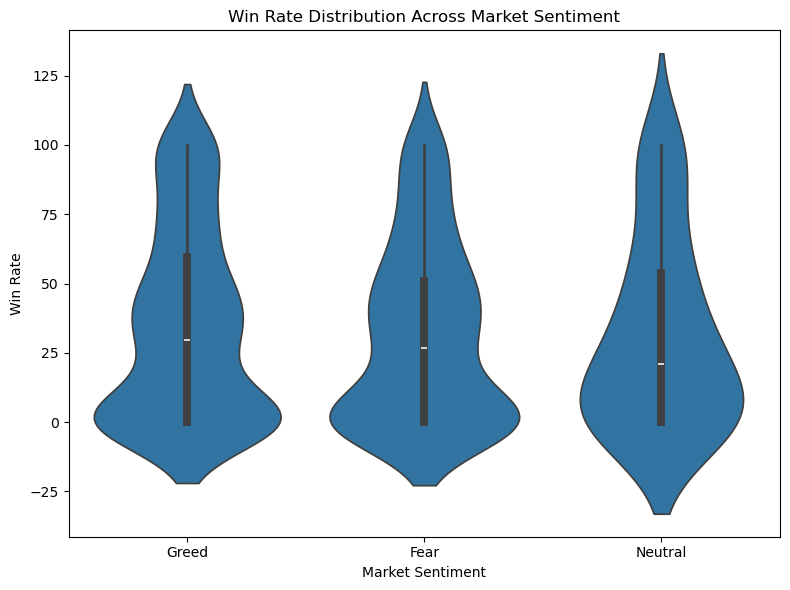

In [130]:
#Chart 4: Win Rate Distribution
plt.figure(figsize=(8,6))

sns.violinplot(
    data=merged_data,
    x="Market_Sentiment",
    y="Win_Rate"
)

plt.title("Win Rate Distribution Across Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.savefig("images/chart4_winrate.png", dpi=300)
plt.show()

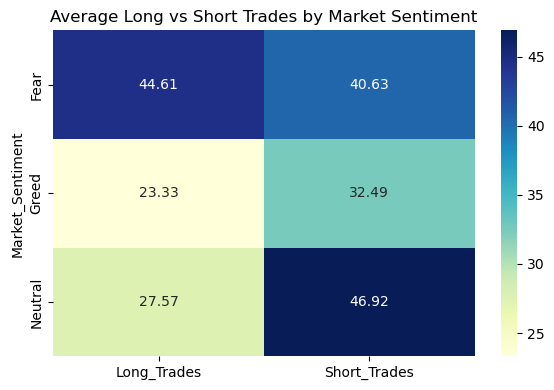

In [131]:
#Chart 5: Long vs Short Trading Bias (Heatmap)
import seaborn as sns

bias = merged_data.groupby("Market_Sentiment")[["Long_Trades","Short_Trades"]].mean()

plt.figure(figsize=(6,4))

sns.heatmap(
    bias,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Long vs Short Trades by Market Sentiment")

plt.tight_layout()
plt.savefig("images/chart5_long_short_heatmap.png", dpi=300)
plt.show()

# Step 5: Data Visualization & Insights

To better understand trader behavior under different market sentiment conditions, multiple visualizations were created using Matplotlib and Seaborn.

The charts illustrate differences in:

- Daily Profit & Loss (PnL)
- Trading Frequency
- Position Exposure
- Win Rate
- Long and Short Trading Bias

These visualizations complement the statistical analysis performed in Step 3 and help identify behavioral patterns across different trader segments and market sentiment conditions.